# HAdam energy growth: a quartic counterexample

A scalar, isotropic companion to `demo.ipynb` and `demo_sigma0.ipynb`.
We take $K=I_D$, $F(q;\omega)=\omega q^4/4$, $\omega\sim\mathrm{Bernoulli}(p)$,
and $\beta_2=0$. Stability is **inside** the square root, $\sqrt{v+\epsilon}$.
The population risk is $3pb^2/4$, where $b=\|\Theta\|^2$.

The stationary HAdam energy ODE is
$$\dot b=-2\eta\varphi(b)+\eta^2s(b).$$
Its finite-dimensional radial SDE has the additional term
$2\eta\sqrt{bs(b)/D}\,dW$. This notebook runs the ODE; it does not claim to
simulate finite-dimensional Adam or its startup transient.

Change the parameters below and run all cells. Dependencies: NumPy, SciPy, Matplotlib.
The history sums are evaluated analytically; only two-dimensional Gaussian
expectations are approximated using seeded, scrambled Sobol quadrature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtri
from scipy.stats import qmc
from scipy.interpolate import PchipInterpolator
from scipy.integrate import solve_ivp, quad

beta1, beta2 = 0.25, 0.0
p, eps, eta = 0.5, 1.0, 1.0
b0 = 16.0
b_cap = 1e5               # numerical endpoint, not an observed infinity
T = 0.04
quadrature_power = 16    # 2**power Gaussian pairs per coefficient evaluation
seed = 123
n_grid = 240
assert beta2 == 0, 'The analytic history reduction below requires beta2=0.'
assert 0 <= beta1 < 1 and 0 < p < 1 and eps > 0 and eta > 0
assert 0 < b0 < b_cap and T > 0

## Exact reduction of the stationary coefficients
Let $q=\sqrt b\,Z$, $Z,\xi\sim N(0,1)$ independently,
$a=\omega q^6\xi^2$, and $H=(a+\epsilon)^{-1/2}$.
Put $\mu=\mathbb EH$, $\nu=\mathbb EH^2$, and
$$m=\frac{\beta_1\mu}{1-\beta_1},\qquad
v=\frac{\beta_1^2(\nu-\mu^2)}{1-\beta_1^2}.$$
The future denominators are independent of sample zero, so
$$\begin{aligned}
\varphi(b)&=(1-\beta_1)\mathbb E[\omega q^4\xi^2H]+3p\beta_1b^2\mu,\\
s(b)&=(1-\beta_1)^2\{\mathbb E[aH^2]+2m\mathbb E[aH]+(m^2+v)\mathbb Ea\},
\qquad \mathbb Ea=15pb^3.
\end{aligned}$$
These expressions retain the shared-history covariance in the manuscript.
Bernoulli randomness and $\mathbb Ea$ are integrated exactly.
For numerical conditioning the implementation returns $\varphi(b)/b^2$ and $s(b)/b^3$.

In [2]:
def gaussian_pairs(power, seed):
    u = qmc.Sobol(2, scramble=True, seed=seed).random_base2(power)
    z, x = ndtri(np.clip(u, 1e-15, 1-1e-15)).T
    return z**4 * x**2, z**6 * x**2

pairs = gaussian_pairs(quadrature_power, seed)

def scaled_coefficients(b, beta=beta1, pairs=pairs):
    """Return phi(b)/b**2 and s(b)/b**3, using exact history sums."""
    z4x2, z6x2 = pairs
    h = 1 / np.sqrt(b**3 * z6x2 + eps)
    mu = (1-p) / np.sqrt(eps) + p * h.mean()
    nu = (1-p) / eps + p * (h*h).mean()
    m = beta * mu / (1-beta)
    v = beta**2 * max(nu-mu*mu, 0.0) / (1-beta**2)
    phi_scaled = (1-beta)*p*np.mean(z4x2*h) + 3*p*beta*mu
    sigma_scaled = (1-beta)**2 * (
        p*np.mean(z6x2*h*h) + 2*m*p*np.mean(z6x2*h)
        + (m*m+v)*15*p)
    return np.array([phi_scaled, sigma_scaled])

b_grid = np.geomspace(min(0.01, b0/10), b_cap, n_grid)
coeff = np.array([scaled_coefficients(b) for b in b_grid])
phi_interp = PchipInterpolator(np.log(b_grid), coeff[:, 0], extrapolate=False)
sigma_interp = PchipInterpolator(np.log(b_grid), coeff[:, 1], extrapolate=False)

def scaled_drift(b):
    # b'/b**3; interpolation is confined to its constructed domain.
    logb = np.log(np.clip(b, b_grid[0], b_grid[-1]))
    return -2*eta*phi_interp(logb)/b + eta**2*sigma_interp(logb)

print('Initial energy derivative:', float(b0**3 * scaled_drift(b0)))
print('Initial population risk:', 3*p*b0**2/4)

Initial energy derivative: 951.2951187697008
Initial population risk: 96.0


## Quadrature and analytic checks
Doubling the quadrature size estimates numerical sensitivity; it is not a
rigorous quadrature error bound. The analytic lower bound is
$$s(b)\ge c b^3,\quad c=15p(1-p)(1-\beta_1)^2\beta_1^2/\epsilon.$$
Also $\varphi(b)\le 2p(1-\beta_1)\sqrt b/\pi+3p\beta_1b^2/\sqrt\epsilon$.
If the resulting lower bound for $b'/b^3$ at $b_0$ is positive, it stays
positive for $b\ge b_0$, proving finite-time blow-up independently of the plots.

In [3]:
fine_pairs = gaussian_pairs(quadrature_power+1, seed)
print('b          relative change in phi     relative change in s')
for b in [b0, min(100*b0, b_cap)]:
    coarse = scaled_coefficients(b)
    fine = scaled_coefficients(b, pairs=fine_pairs)
    rel = np.abs(coarse-fine)/np.maximum(np.abs(fine), 1e-15)
    print(f'{b:9.2g}  {rel[0]:24.3e}  {rel[1]:20.3e}')
    assert np.all(np.isfinite(fine)) and np.all(fine >= 0)

c = 15*p*(1-p)*(1-beta1)**2*beta1**2/eps
certified_a = (eta**2*c - 6*eta*p*beta1/(np.sqrt(eps)*b0)
               - 4*eta*p*(1-beta1)/(np.pi*b0**2.5))
assert np.all(coeff[:, 1] >= c*(1-1e-10))
if certified_a > 0:
    upper_time = 1/(2*certified_a*b0**2)
    print(f'Analytic certificate: b′ >= {certified_a:.6g} b^3 for b >= b0.')
    print(f'Blow-up time is at most {upper_time:.8g}.')
else:
    print('This sufficient blow-up certificate does not apply to these parameters.')

# beta1=0 gives s=E[a/(a+eps)] <= p exactly.
s_no_momentum = scaled_coefficients(b0, beta=0)[1]*b0**3
assert 0 <= s_no_momentum <= p*(1+1e-12)

b          relative change in phi     relative change in s
       16                 1.000e-06             2.894e-06
  1.6e+03                 1.207e-06             3.389e-06
Analytic certificate: b′ >= 0.0844947 b^3 for b >= b0.
Blow-up time is at most 0.023115365.


## Integrate the ODE without overflowing
Use $y=b^{-2}$, so $y'=-2b'/b^3$. Stop at $b=b_{\rm cap}$;
the solver never steps through the singularity. A second event stops at the
lower edge of the coefficient table if parameters instead produce decay.
Threshold hitting times and the analytic bound distinguish finite-time
growth from solver overflow. The dashed control sets $\beta_1=0$, leaving
all other parameters unchanged.

In [4]:
def upper_event(t, y):
    return y[0] - b_cap**-2
upper_event.terminal = True
upper_event.direction = -1

def lower_event(t, y):
    return y[0] - b_grid[0]**-2
lower_event.terminal = True
lower_event.direction = 1

def reciprocal_rhs(t, y):
    b = np.clip(1/np.sqrt(max(y[0], b_cap**-2)), b_grid[0], b_cap)
    return [-2*float(scaled_drift(b))]

sol = solve_ivp(reciprocal_rhs, [0, T], [b0**-2], dense_output=True,
                rtol=1e-9, atol=1e-13, max_step=T/200,
                events=[upper_event, lower_event])
assert sol.success, sol.message
time = np.linspace(0, sol.t[-1], 1200)
y = sol.sol(time)[0]
energy = 1/np.sqrt(np.maximum(y, b_cap**-2))
print('ODE:', sol.message)
print(f'Last time {time[-1]:.9g}; last energy {energy[-1]:.6g}')
print('Reached energy cap:', bool(len(sol.t_events[0])))

control_coeff = np.array([scaled_coefficients(b, beta=0) for b in b_grid])
control_phi = PchipInterpolator(np.log(b_grid), control_coeff[:,0])
control_sigma = PchipInterpolator(np.log(b_grid), control_coeff[:,1])
def control_rhs(t, logb):
    b = np.exp(logb[0])
    return [-2*eta*b*float(control_phi(logb[0]))
            + eta**2*b*b*float(control_sigma(logb[0]))]
control = solve_ivp(control_rhs, [0, T], [np.log(b0)],
                    rtol=1e-9, atol=1e-11, dense_output=True, max_step=T/200)
assert control.success
control_time = np.linspace(0, T, 600)
control_b = np.exp(control.sol(control_time)[0])
assert control_b.min() >= b_grid[0] and control_b.max() <= b_cap

# Independent integration of dt/db, valid when the energy increases throughout.
if np.all(scaled_drift(np.geomspace(b0, b_cap, 500)) > 0):
    print('Energy threshold     hitting time (quadrature of dt/db)')
    for threshold in np.geomspace(b0*2, b_cap, 6):
        hit, _ = quad(lambda u: np.exp(-2*u)/float(scaled_drift(np.exp(u))),
                      np.log(b0), np.log(threshold), epsabs=1e-10, limit=200)
        print(f'{threshold:16.5g}     {hit:.10f}')
    if len(sol.t_events[0]):
        assert abs(hit-sol.t_events[0][0]) < 1e-6

ODE: A termination event occurred.
Last time 0.00856423936; last energy 100000
Reached energy cap: True
Energy threshold     hitting time (quadrature of dt/db)
              32     0.0063540522
             160     0.0084689174
             800     0.0085602473
            4000     0.0085640761
           20000     0.0085642329
           1e+05     0.0085642396


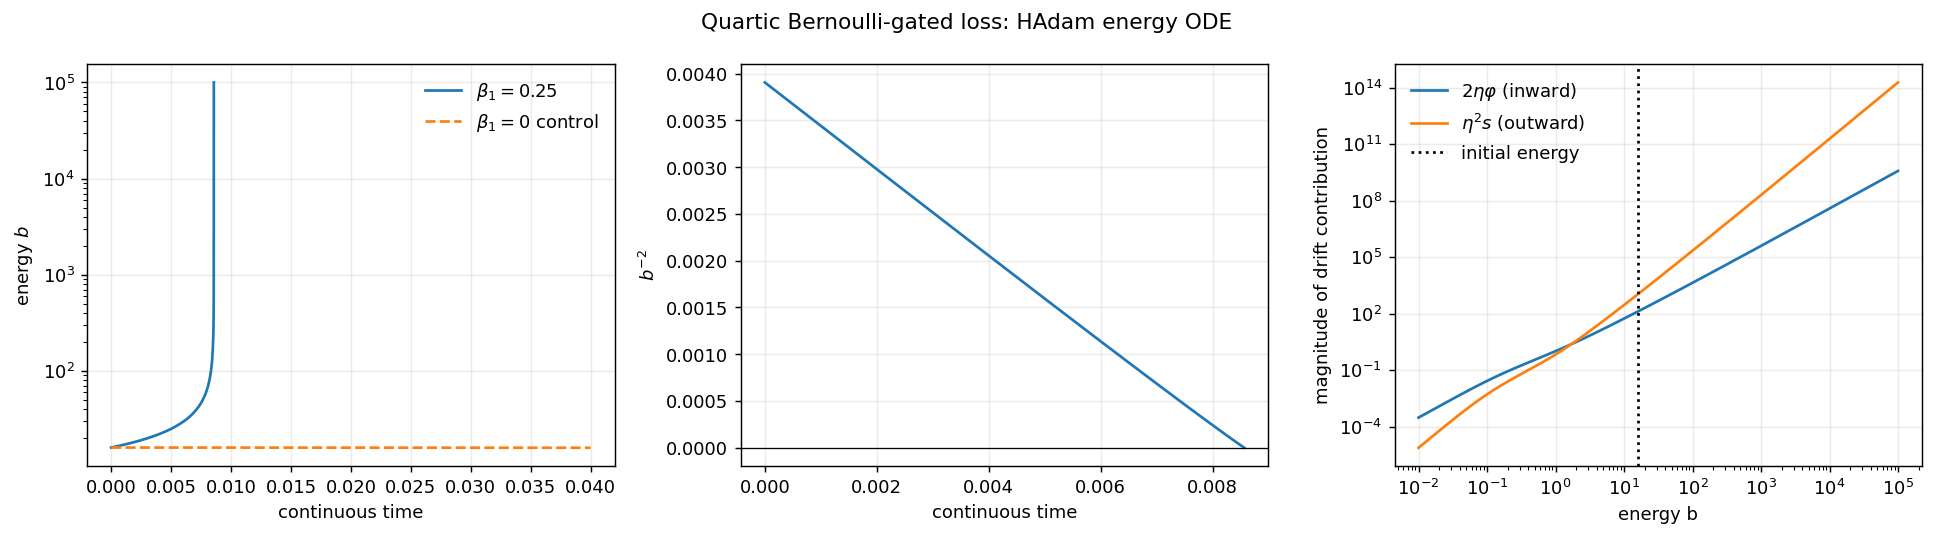

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(time, energy, label=fr'$\beta_1={beta1}$')
axes[0].plot(control_time, control_b, '--', label=r'$\beta_1=0$ control')
axes[0].set(xlabel='continuous time', ylabel=r'energy $b$', yscale='log')
axes[0].legend(frameon=False)
axes[1].plot(time, y, label=r'$y=b^{-2}$')
axes[1].axhline(0, color='k', lw=0.7)
axes[1].set(xlabel='continuous time', ylabel=r'$b^{-2}$')
axes[2].loglog(b_grid, 2*eta*coeff[:,0]*b_grid**2, label=r'$2\eta\varphi$ (inward)')
axes[2].loglog(b_grid, eta**2*coeff[:,1]*b_grid**3, label=r'$\eta^2s$ (outward)')
axes[2].axvline(b0, color='k', ls=':', label='initial energy')
axes[2].set(xlabel='energy b', ylabel='magnitude of drift contribution')
axes[2].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle('Quartic Bernoulli-gated loss: HAdam energy ODE')
fig.tight_layout()
plt.show()

The plotted endpoint is a finite threshold crossing, not a numerical observation of infinity.
Increase `b_cap` to check stabilization of the hitting times, and increase
`quadrature_power` and `n_grid` to check numerical resolution. The analytic
certificate above supplies the blow-up conclusion when it is positive.

This example uses the allowed endpoint `beta2=0`; its coefficient reduction
must not be reused unchanged for positive `beta2`. It disproves a global
stopping-time removal under the full stated parameter range, rather than
claiming instability for every Adam parameter choice.